In [78]:
import numpy as np
import os
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import csv
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


#### Imports

In [2]:

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

with open("../Code/Data/GJ_1214b_gravity_test.csv", newline="") as PlanetaryParametersFile:   
	reader = csv.reader(PlanetaryParametersFile)
	header = next(reader)
	tsm_idx = header.index("pl_tsm")
	temp_idx = header.index("pl_Teq")
	gravity_idx = header.index("g_planet_cgs")
	rs_idx = header.index("st_rad")
	data = []
	planetNames = []
	tsm_values = []
	temp_values = []
	gravity_values = []
	rs_values = []
	for row in reader:
		row = [item.strip() for item in row]
		if len(row) == 0:
			continue
		name, *nums = row
		conv = [float(item) if item != "" else np.nan for item in nums]
		data.append(conv)
		planetNames.append(name)
		tsm = float(nums[tsm_idx - 1]) if nums[tsm_idx - 1] != "" else np.nan
		tsm_values.append(tsm)
		temp = float(nums[temp_idx - 1]) if nums[temp_idx - 1] != "" else np.nan
		temp_values.append(temp)
		gravity = float(nums[gravity_idx - 1]) if nums[gravity_idx - 1] != "" else np.nan
		gravity_values.append(gravity)
		rs = float(nums[rs_idx - 1]) if nums[rs_idx - 1] != "" else np.nan
		rs_values.append(rs)
	planetaryParameters = np.array(data, dtype=float)
	

#### Cross section stuff 

In [64]:
#This just does the stuff that only needs to be done once for the cross sections

xsec_h2o = np.load('../GivenResources/cross_section_files/Cross_section_files/h2o_xsec.npy')
lam_h2o = np.load('../GivenResources/cross_section_files/Cross_section_files/h2o_lam.npy')*1e6 # convert to microns
P_h2o = np.power(10.0,np.load('../GivenResources/cross_section_files/Cross_section_files/h2o_P.npy')) # already in Pa
T_h2o = np.load('../GivenResources/cross_section_files/Cross_section_files/h2o_T.npy')

# Read in CO2 cross section data
xsec_co2 = np.load('../GivenResources/cross_section_files/Cross_section_files/co2_xsec.npy')
lam_co2 = np.load('../GivenResources/cross_section_files/Cross_section_files/co2_lam.npy')*1e6 # convert to microns
P_co2 = np.power(10.0,np.load('../GivenResources/cross_section_files/Cross_section_files/co2_P.npy')) # already in Pa
T_co2 = np.load('../GivenResources/cross_section_files/Cross_section_files/co2_T.npy')

# Read in CH4 cross section data
xsec_ch4 = np.load('../GivenResources/cross_section_files/Cross_section_files/ch4_xsec.npy')
lam_ch4 = np.load('../GivenResources/cross_section_files/Cross_section_files/ch4_lam.npy')*1e6 # convert to microns
P_ch4 = np.power(10.0,np.load('../GivenResources/cross_section_files/Cross_section_files/ch4_P.npy')) # already in Pa
T_ch4 = np.load('../GivenResources/cross_section_files/Cross_section_files/ch4_T.npy')

#read in CO cross section data
xsec_co = np.load('../GivenResources/cross_section_files/Cross_section_files/co_xsec.npy')
lam_co = np.load('../GivenResources/cross_section_files/Cross_section_files/co_lam.npy')*1e6 # convert to microns   
P_co = np.power(10.0,np.load('../GivenResources/cross_section_files/Cross_section_files/co_P.npy')) # already in Pa
T_co = np.load('../GivenResources/cross_section_files/Cross_section_files/co_T.npy')

# H2-H2 and He-H2 molecule pairs cause absorption through a process called "collision-induced absorption". This data is wavelength- and temperature-dependent, but not pressure-dependent.
xsec_h2h2 = np.load('../GivenResources/cross_section_files/Cross_section_files/h2_h2_xsec.npy')
lam_h2h2 = np.load('../GivenResources/cross_section_files/Cross_section_files/h2_h2_lam.npy')

xsec_heh2 = np.load('../GivenResources/cross_section_files/Cross_section_files/he_h2_xsec.npy')
lam_heh2 = np.load('../GivenResources/cross_section_files/Cross_section_files/he_h2_lam.npy')

logX = dict()
logX['h2o'] = -1.1
logX['ch4'] = -1.74
logX['co'] = -2.0
logX['co2'] = -1.7
#logX['nh3'] = -3.0

## We'll also need to know the mean molecular weights of each molecule (here in units of amu) ##
mmw = dict()
mmw['h2o'] = 18.0
mmw['ch4'] = 16.0
mmw['co'] = 28.0
mmw['co2'] = 44.0
mmw['h2'] = 2.0
mmw['he'] = 4.0


# Now we can 'fill' the rest of the atmosphere with H2 and He, which are typically the most abudnant background gases.
# Let's assume that the ratio of H2 to He is the same as that in the Sun, i.e. X_He/X_H2 = 0.17 (Asplund et al. 2009 shows that X_He/X_H = 0.085, and going from H to H2 means doubling that)
# Then X_H2 + X_He = 1 - X_rest

X_rest = np.sum([np.power(10.0,logX[key]) for key in logX.keys()])
X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
X_He = 0.17 * X_H2

# Now let's add H2 and He to the logX dictionary

logX['h2'] = np.log10(X_H2)
logX['he'] = np.log10(X_He)

xsec_dict = dict()
lam_dict = dict()
P_dict = dict()
T_dict = dict()


lam = np.linspace(0.61,5.0,500)
# lam = np.linspace(0.61,5.0,500)
P = np.logspace(2.0,-8,100) * 1.0e5 #pasted in, belongs below really
# T = Tp*np.ones_like(P) #same

log_xsec_dict = dict()

lamlam, PP = np.meshgrid(lam, P, indexing="ij")

# ---- H2O ----
interp_h2o = RegularGridInterpolator(
	(lam_h2o, P_h2o, T_h2o),
	xsec_h2o,
	method='linear', bounds_error=False,
	fill_value=None)
#log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))

# ---- CO2 ----
interp_co2 = RegularGridInterpolator(
	(lam_co2, P_co2, T_co2),
	xsec_co2,
	method='linear', bounds_error=False,
	fill_value=None
)
#log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))

# ---- CH4 ----
interp_ch4 = RegularGridInterpolator(
	(lam_ch4, P_ch4, T_ch4),
	xsec_ch4,
	method='linear', bounds_error=False,
	fill_value=None
)
#log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))

interp_co = RegularGridInterpolator(
	(lam_co, P_co, T_co),
	xsec_co,
	method='linear', bounds_error=False,
	fill_value=None
)
#log_xsec_dict['co'] = interp_co2((lamlam, PP, T[0]))

log_cia_dict = dict()
log_cia_dict['h2h2'] = np.interp(lam, lam_h2h2, xsec_h2h2)
log_cia_dict['heh2'] = np.interp(lam, lam_heh2, xsec_heh2)


In [17]:
print(np.shape(planetaryParameters))

(16, 43)


#### Planet parameters 

In [65]:
#these are all gonna be the same for gj1214b
Rp = 2.733                        ## planet radius in units of Earth radii
Mp = 8.41
mu = 4.88                                                   ## mean molecular weight in atomic mass units
Pcloud = 100
Pref = 0.01                                                     ## pressure at top of cloud deck in bar  
Rs = 0.2162                          ## stellar radius in units of Solar radii
print(Rs)     
Rp *= const.R_earth.value                                       ## Convert Rp from units of R_Earth to m
Rs *= const.R_sun.value                                         ## Convert Rs from units of R_Sun to m
Pcloud *= 1.0e5                                                 ## Convert Pcloud from bar to Pa
Pref *= 1.0e5                                                   ## Convert Pref from bar to Pa
mu *= sc.u                                                      ## Convert mu from atomic mass units to kg

0.2162


In [66]:
Temps = np.linspace(200,1000,20)
# Temps = [500]
gravities = np.linspace(300, 3000, 20)
print(gravities)

[ 300.          442.10526316  584.21052632  726.31578947  868.42105263
 1010.52631579 1152.63157895 1294.73684211 1436.84210526 1578.94736842
 1721.05263158 1863.15789474 2005.26315789 2147.36842105 2289.47368421
 2431.57894737 2573.68421053 2715.78947368 2857.89473684 3000.        ]


In [ ]:
# with saving and loading

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

# Temps = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000])
# gravities = np.linspace(300, 3000, 10)

# Create meshgrid (matching RegularGridInterpolator ordering)
T_mesh, g_mesh = np.meshgrid(Temps, gravities, indexing='ij')

# Preallocate A_H grid
A_H_grid = np.zeros((len(Temps), len(gravities)), dtype=float)


rowCount= 0

for iT in range(len(Temps)):
	for ig in range(len(gravities)):

		Temp = Temps[iT]
		grav = gravities[ig]

		#while rowCount < 10:
		#PName = planetNames[rowCount]                                   ## planet name   
		#print(f"---Analysing gj1214b for T={Temp}K and g={grav} cm/s^2---")
		# print(f"Star Manitude: {planetaryParameters[rowCount][20]}")
		Tp = Temp                        ## planet temperature in K


		# P = np.logspace(2.0,-8,100) * 1.0e5 defined in above cell identically
		# T = Tp*np.ones_like(P)
		lam = np.linspace(0.61,5.0,500)
		P = np.logspace(2.0,-8,100) * 1.0e5 #pasted in, belongs below really
		T = Tp*np.ones_like(P) #same
		n = P/(sc.k*T)
		rho = mu*n
		gp = grav / 100.0 # convert from cgs to SI (CHANGE THIS)
		print(f"Gravity: {gp} m/s^2")
		# gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
		# print(gp)
		r = np.zeros_like(P)
		g = np.zeros_like(P)
		i_Rp = np.argmin(np.abs(P-Pref))
		r[i_Rp] = Rp
		g[i_Rp] = gp


		for i in range(i_Rp + 1, len(P)):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
			r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

		for i in range(i_Rp-1, -1, -1):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
			r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])





		log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))
		log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))
		log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))
		log_xsec_dict['co'] = interp_co((lamlam, PP, T[0]))

		sum_nsigma = np.zeros((len(lam), len(P)))
		for mol in log_xsec_dict.keys():
			sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

		integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
		integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

		exptau = np.zeros((len(P),len(lam)))
		transit_depth = np.zeros((len(lam)))

		# Compute the total optical depth at each impact parameter and wavelength #

		opacity = sum_nsigma #(kappa+sigma)
		# For each layer of atmosphere

		for i in range(len(r)-1):

			s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
			ds = s_tot[1:]-s_tot[:-1]

			tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

			# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
			if P[i] > Pcloud:
				tau_tot += 1000.0

			# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
			exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


		# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
		for i in range(len(r)-1):

			# Rays travelling through atmosphere above Rp
			if (r[i] >= Rp):
				integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

			# Rays travelling through atmosphere below Rp
			if (r[i] < Rp):
				integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

		# Compute effective transit depth (transmission spectrum) #
		transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)

		np.savetxt(f'planet_spectrum_{Temp},{grav}.txt', np.column_stack((lam, transit_depth)), header='Wavelength(micron)   Transit_Depth(rp^2/r*^2)', fmt='%10.6f')


		# 1. Load your spectrum data
		loaded_spec = np.loadtxt(f"planet_spectrum_{Temp},{grav}.txt")
		lam_data = loaded_spec[:, 0]
		depth_data = loaded_spec[:, 1]

		left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
		# Extract values in that window
		left_depth_values = depth_data[left_mask]
		left_lam_values = lam_data[left_mask]
		# Take averages
		left_val = np.mean(left_depth_values)
		left_lam_target = np.mean(left_lam_values)

		# # 3. Find Right Trough (4.6-4.8 um)
		# right_mask = (lam_data >= 1.45) & (lam_data <= 1.6)   #H2O feature
		# # right_mask = (lam_data >= 4.6) & (lam_data <= 4.8)   # CO2 feature
		# right_val = np.min(depth_data[right_mask])
		# right_lam_target = lam_data[right_mask][np.argmin(depth_data[right_mask])]

		# 4. Identify the Peak region between those two troughs
		# peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
		peak_mask = (lam_data >= 4.245) & (lam_data <= 4.275)   # CO2 feature
		# Extract values in that window
		peak_region_depths = depth_data[peak_mask]
		peak_x_values = lam_data[peak_mask]

		# 5. Calculate Height and the Scatter Error
		peak_val = np.mean(peak_region_depths)
		peak_x_value = np.mean(peak_x_values)
		feature_height_ratio = (peak_val - left_val)
		feature_height_ppm = (peak_val - left_val) * 1e6
		feature_height_ppm_Array.append(feature_height_ppm)

		# The "Error" is the standard deviation of the points in the peak region
		# This represents the local variation/noise in your model
		peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

		# plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
		# plt.scatter(left_lam_target, left_val*1e6, color='blue', label='Left Trough')
		# plt.scatter(right_lam_target, right_val*1e6, color='red', label='Right Trough')
		# plt.scatter(lam_data[peak_mask][np.argmax(peak_region_depths)], peak_val*1e6, color='green', label='Peak')
		# plt.xlabel('Wavelength (microns)')
		# plt.ylabel('Transit Depth (ppm)')
		# plt.title(f'Transmission Spectrum of {Temp},{grav}')
		# #plt.xlim([0.5,])
		# plt.xlim([3.0,5.0])
		# plt.show()

		print(f"--- {Temp},{grav} ---")
		print(f"Feature Height: {feature_height_ppm:.2f} ppm")
		print(peak_x_value)
		# print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")
		mu2 = 4.88
		scale_height = (sc.k * Tp) / (mu2 * gp * sc.m_p)
		scale_height_array.append(scale_height)
		# print('Scale Height is,', scale_height)

		A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)

		A_H_grid[iT, ig] = A_H
		#A_H_Array.append(A_H)
		print('A_H =', A_H)
		# print('Feature Height (ppm) =', feature_height_ppm) 
		# print('Scale Height (m) =', scale_height)
		# print('Tp = ', Tp) 
		# print('Gravity =', gp) 
		# print('Mean Molecular Weight (kg) =', mu) 
		# print('Planet Radius (m) =', Rp) 
		# print('Stellar Radius (m) =', Rs) 



	# print('Tsm values:', tsm_values)
	# print('A/H values:', A_H_Array)


	# import pandas as pd
	# df = pd.DataFrame({
	# 	'Planet Name': planetNames,
	# 	'Tsm': tsm_values,
	# 	'Temp': temp_values,
	# 	'A/H': A_H_Array,
	# 	'Feature Height (ppm)': feature_height_ppm_Array,
	# 	'scale height (m)': scale_height_array
	# })
	# df.to_csv('Planetary_Parameters_and_Spectral_Features.csv', index=False)

Gravity: 3.0 m/s^2
--- 200.0,300.0 ---
Feature Height: 2520.50 ppm
4.261002
A_H = 14.504632182601412
Gravity: 4.421052631578948 m/s^2
--- 200.0,442.10526315789474 ---
Feature Height: 1623.67 ppm
4.261002
A_H = 13.769599975782056
Gravity: 5.842105263157895 m/s^2
--- 200.0,584.2105263157895 ---
Feature Height: 1196.50 ppm
4.261002
A_H = 13.408520010437668
Gravity: 7.263157894736842 m/s^2
--- 200.0,726.3157894736842 ---
Feature Height: 946.67 ppm
4.261002
A_H = 13.1892874801021
Gravity: 8.68421052631579 m/s^2
--- 200.0,868.421052631579 ---
Feature Height: 782.33 ppm
4.261002
A_H = 13.032296190821997
Gravity: 10.105263157894738 m/s^2
--- 200.0,1010.5263157894738 ---
Feature Height: 666.83 ppm
4.261002
A_H = 12.925986333836747
Gravity: 11.526315789473683 m/s^2
--- 200.0,1152.6315789473683 ---
Feature Height: 580.50 ppm
4.261002
A_H = 12.834870810637113
Gravity: 12.947368421052632 m/s^2
--- 200.0,1294.7368421052631 ---
Feature Height: 513.83 ppm
4.261002
A_H = 12.761524076449364
Gravity: 14.

In [67]:
# without saving and loading

A_H_Array = []
feature_height_ppm_Array = []
scale_height_array = []

# Temps = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000])
# gravities = np.linspace(300, 3000, 10)

# Create meshgrid (matching RegularGridInterpolator ordering)
T_mesh, g_mesh = np.meshgrid(Temps, gravities, indexing='ij')

# Preallocate A_H grid
A_H_grid = np.zeros((len(Temps), len(gravities)), dtype=float)


rowCount= 0

for iT in range(len(Temps)):
	for ig in range(len(gravities)):

		Temp = Temps[iT]
		grav = gravities[ig]

		#while rowCount < 10:
		#PName = planetNames[rowCount]                                   ## planet name   
		#print(f"---Analysing gj1214b for T={Temp}K and g={grav} cm/s^2---")
		# print(f"Star Manitude: {planetaryParameters[rowCount][20]}")
		Tp = Temp                        ## planet temperature in K


		# P = np.logspace(2.0,-8,100) * 1.0e5 defined in above cell identically
		# T = Tp*np.ones_like(P)
		lam = np.linspace(0.61,5.0,500)
		P = np.logspace(2.0,-8,100) * 1.0e5 #pasted in, belongs below really
		T = Tp*np.ones_like(P) #same
		n = P/(sc.k*T)
		rho = mu*n
		gp = grav / 100.0 # convert from cgs to SI (CHANGE THIS)
		print(f"Gravity: {gp} m/s^2")
		# gp = (sc.G * Mp * const.M_earth.value) / (Rp)**2
		# print(gp)
		r = np.zeros_like(P)
		g = np.zeros_like(P)
		i_Rp = np.argmin(np.abs(P-Pref))
		r[i_Rp] = Rp
		g[i_Rp] = gp


		for i in range(i_Rp + 1, len(P)):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i-1] * r[i-1])
			r[i] = r[i-1] - ( sc.k * 0.5 * (T[i-1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i-1]) 

		for i in range(i_Rp-1, -1, -1):
			g[i] = g[i_Rp] * r[i_Rp] * r[i_Rp] / (r[i+1] * r[i+1])
			r[i] = r[i+1] - ( sc.k * 0.5 * (T[i+1]+T[i]) / (mu * g[i]) ) * np.log(P[i]/P[i+1])





		log_xsec_dict['h2o'] = interp_h2o((lamlam, PP, T[0]))
		log_xsec_dict['co2'] = interp_co2((lamlam, PP, T[0]))
		log_xsec_dict['ch4'] = interp_ch4((lamlam, PP, T[0]))
		log_xsec_dict['co'] = interp_co((lamlam, PP, T[0]))

		sum_nsigma = np.zeros((len(lam), len(P)))
		for mol in log_xsec_dict.keys():
			sum_nsigma += n[np.newaxis,:]*np.power(10.0,logX[mol])*np.power(10.0,log_xsec_dict[mol])

		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['h2'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['h2h2'])[:,np.newaxis]
		sum_nsigma += n[np.newaxis,:]*n[np.newaxis,:]*np.power(10.0,logX['he'])*np.power(10.0,logX['h2'])*np.power(10.0,log_cia_dict['heh2'])[:,np.newaxis]

		integral_gt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r>Rp" integral
		integral_lt_Rp = np.zeros((len(lam))) # initialise an array where we'll store the "r<Rp" integral

		exptau = np.zeros((len(P),len(lam)))
		transit_depth = np.zeros((len(lam)))

		# Compute the total optical depth at each impact parameter and wavelength #

		opacity = sum_nsigma #(kappa+sigma)
		# For each layer of atmosphere

		for i in range(len(r)-1):

			s_tot = np.sqrt(r[i:]*r[i:]-r[i]*r[i])
			ds = s_tot[1:]-s_tot[:-1]

			tau_tot = np.sum((opacity[:, i:-1] + opacity[:, i+1:])*ds[np.newaxis,:],axis=-1)

			# If r[i] is deeper that the top of the cloud, the atmosphere here is fully opaque and tau is very large.
			if P[i] > Pcloud:
				tau_tot += 1000.0

			# We need e^(-tau) for the integral, so let's calculate that here. Adding 1.0-e-250 avoids errors when taking the log of this in cases where e^-tau is essentially zero.
			exptau[i, :] = np.exp(-1.0*tau_tot) + 1.0e-250


		# Compute transit depth terms. Note that we take an average of the i^th and (i+1)^th terms in the integrals.
		for i in range(len(r)-1):

			# Rays travelling through atmosphere above Rp
			if (r[i] >= Rp):
				integral_gt_Rp[:] += 0.5*((r[i]*(1.0 - exptau[i, :]) + (r[i+1]*(1.0 - exptau[i+1, :])))*(r[i+1] - r[i]))

			# Rays travelling through atmosphere below Rp
			if (r[i] < Rp):
				integral_lt_Rp[:] += 0.5*((r[i]*(exptau[i, :]) + (r[i+1]*(exptau[i+1, :])))*(r[i+1] - r[i]))

		# Compute effective transit depth (transmission spectrum) #
		transit_depth[:] = (Rp*Rp + 2.0*integral_gt_Rp[:] - 2.0*integral_lt_Rp[:])/(Rs*Rs)

		lam_data = lam
		depth_data = transit_depth



		left_mask = (lam_data >= 4.1) & (lam_data <= 4.15)   # CO2 feature
		# Extract values in that window
		left_depth_values = depth_data[left_mask]
		left_lam_values = lam_data[left_mask]
		# Take averages
		left_val = np.mean(left_depth_values)
		left_lam_target = np.mean(left_lam_values)

		# # 3. Find Right Trough (4.6-4.8 um)
		# right_mask = (lam_data >= 1.45) & (lam_data <= 1.6)   #H2O feature
		# # right_mask = (lam_data >= 4.6) & (lam_data <= 4.8)   # CO2 feature
		# right_val = np.min(depth_data[right_mask])
		# right_lam_target = lam_data[right_mask][np.argmin(depth_data[right_mask])]

		# 4. Identify the Peak region between those two troughs
		# peak_mask = (lam_data >= left_lam_target) & (lam_data <= right_lam_target)
		peak_mask = (lam_data >= 4.245) & (lam_data <= 4.275)   # CO2 feature
		# Extract values in that window
		peak_region_depths = depth_data[peak_mask]
		peak_x_values = lam_data[peak_mask]

		# 5. Calculate Height and the Scatter Error
		peak_val = np.mean(peak_region_depths)
		peak_x_value = np.mean(peak_x_values)
		feature_height_ratio = (peak_val - left_val)
		feature_height_ppm = (peak_val - left_val) * 1e6
		feature_height_ppm_Array.append(feature_height_ppm)

		# The "Error" is the standard deviation of the points in the peak region
		# This represents the local variation/noise in your model
		peak_scatter_error_ppm = np.std(peak_region_depths) * 1e6

		# plt.plot(lam,transit_depth*1e6) #convert transit_depth into units of ppm
		# plt.scatter(left_lam_target, left_val*1e6, color='blue', label='Left Trough')
		# plt.scatter(right_lam_target, right_val*1e6, color='red', label='Right Trough')
		# plt.scatter(lam_data[peak_mask][np.argmax(peak_region_depths)], peak_val*1e6, color='green', label='Peak')
		# plt.xlabel('Wavelength (microns)')
		# plt.ylabel('Transit Depth (ppm)')
		# plt.title(f'Transmission Spectrum of {Temp},{grav}')
		# #plt.xlim([0.5,])
		# plt.xlim([3.0,5.0])
		# plt.show()

		print(f"--- {Temp},{grav} ---")
		print(f"Feature Height: {feature_height_ppm:.2f} ppm")
		print(peak_x_value)
		# print(f"Model Scatter (Error): {peak_scatter_error_ppm:.2f} ppm")
		mu2 = 4.88
		scale_height = (sc.k * Tp) / (mu2 * gp * sc.m_p)
		scale_height_array.append(scale_height)
		# print('Scale Height is,', scale_height)

		A_H = feature_height_ratio * (Rs ** 2) / (2*scale_height*Rp)

		A_H_grid[iT, ig] = A_H
		#A_H_Array.append(A_H)
		print('A_H =', A_H)
		# print('Feature Height (ppm) =', feature_height_ppm) 
		# print('Scale Height (m) =', scale_height)
		# print('Tp = ', Tp) 
		# print('Gravity =', gp) 
		# print('Mean Molecular Weight (kg) =', mu) 
		# print('Planet Radius (m) =', Rp) 
		# print('Stellar Radius (m) =', Rs) 



	# print('Tsm values:', tsm_values)
	# print('A/H values:', A_H_Array)


	# import pandas as pd
	# df = pd.DataFrame({
	# 	'Planet Name': planetNames,
	# 	'Tsm': tsm_values,
	# 	'Temp': temp_values,
	# 	'A/H': A_H_Array,
	# 	'Feature Height (ppm)': feature_height_ppm_Array,
	# 	'scale height (m)': scale_height_array
	# })
	# df.to_csv('Planetary_Parameters_and_Spectral_Features.csv', index=False)

Gravity: 3.0 m/s^2
--- 200.0,300.0 ---
Feature Height: 2470.79 ppm
4.2610020040080165
A_H = 14.218542460419203
Gravity: 4.421052631578948 m/s^2
--- 200.0,442.10526315789474 ---
Feature Height: 1600.04 ppm
4.2610020040080165
A_H = 13.569231648786996
Gravity: 5.842105263157895 m/s^2
--- 200.0,584.2105263157895 ---
Feature Height: 1181.95 ppm
4.2610020040080165
A_H = 13.24549974988197
Gravity: 7.263157894736842 m/s^2
--- 200.0,726.3157894736842 ---
Feature Height: 936.51 ppm
4.2610020040080165
A_H = 13.047812663280107
Gravity: 8.68421052631579 m/s^2
--- 200.0,868.421052631579 ---
Feature Height: 775.14 ppm
4.2610020040080165
A_H = 12.912476218344814
Gravity: 10.105263157894738 m/s^2
--- 200.0,1010.5263157894738 ---
Feature Height: 660.99 ppm
4.2610020040080165
A_H = 12.812758596256607
Gravity: 11.526315789473683 m/s^2
--- 200.0,1152.6315789473683 ---
Feature Height: 576.00 ppm
4.2610020040080165
A_H = 12.735429143982259
Gravity: 12.947368421052632 m/s^2
--- 200.0,1294.7368421052631 ---
Fe

In [16]:
np.savez_compressed(
    "AH_grid_data.npz",
    A_H_grid=A_H_grid,
    Temps=Temps,
    gravities=gravities
)


In [ ]:
# data = np.load("AH_grid_data.npz")

# A_H_grid = data["A_H_grid"]
# Temps = data["Temps"]
# gravities = data["gravities"]

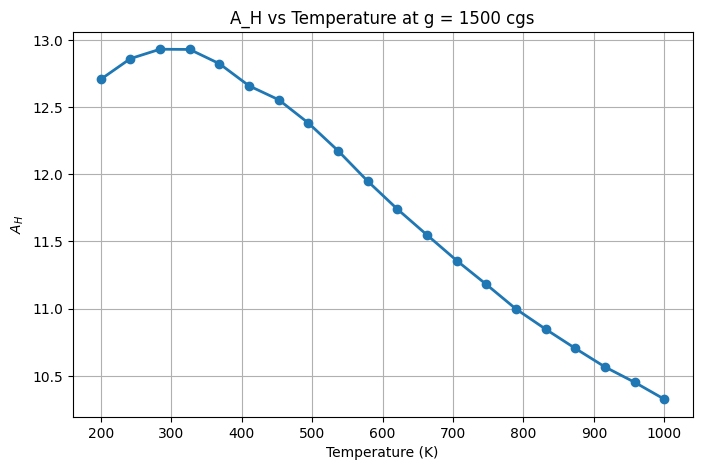

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# Pick the gravity value you want
g_fixed = 1500 #for example, in the same units as your gravities array

# Find the index of the closest gravity in your grid
g_idx = np.argmin(np.abs(gravities - g_fixed))

# Extract A_H values for this gravity across all Temps
A_H_slice = A_H_grid[:, g_idx]

# Plot
plt.figure(figsize=(8,5))
plt.plot(Temps, A_H_slice, marker='o', lw=2)
plt.xlabel('Temperature (K)')
plt.ylabel(r'$A_H$')
plt.title(f'A_H vs Temperature at g = {g_fixed:.0f} cgs')
plt.grid(True)
plt.show()


#### Interpolater

In [81]:
A_H_grid.shape
interp = RegularGridInterpolator(
    (Temps, gravities),
    A_H_grid,
    method='linear', bounds_error=False,
	fill_value=None
    
)



In [82]:
interp([[518,1105.67]])[0]


np.float64(12.58716180180886)

In [71]:
print(A_H_grid.shape)
print(len(Temps), len(gravities))

(20, 20)
20 20


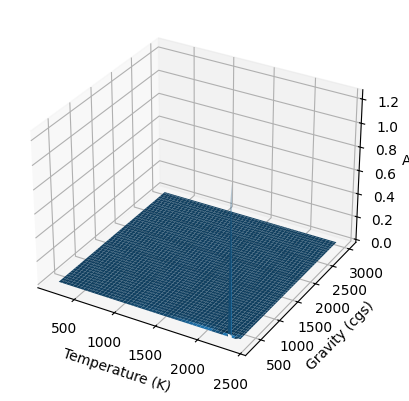

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create meshgrid for plotting only
T_mesh, g_mesh = np.meshgrid(Temps, gravities, indexing='ij')

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(T_mesh, g_mesh, A_H_grid)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Gravity (cgs)')
ax.set_zlabel('A_H')

plt.show()


In [ ]:
# A_H_grid = np.zeros((len(Temps), len(gravities)))

# mesh = np.meshgrid(gravities, Temps, indexing="ij")
# shape = mesh[0].shape
# print(shape)




(10, 9)


#### Plotting

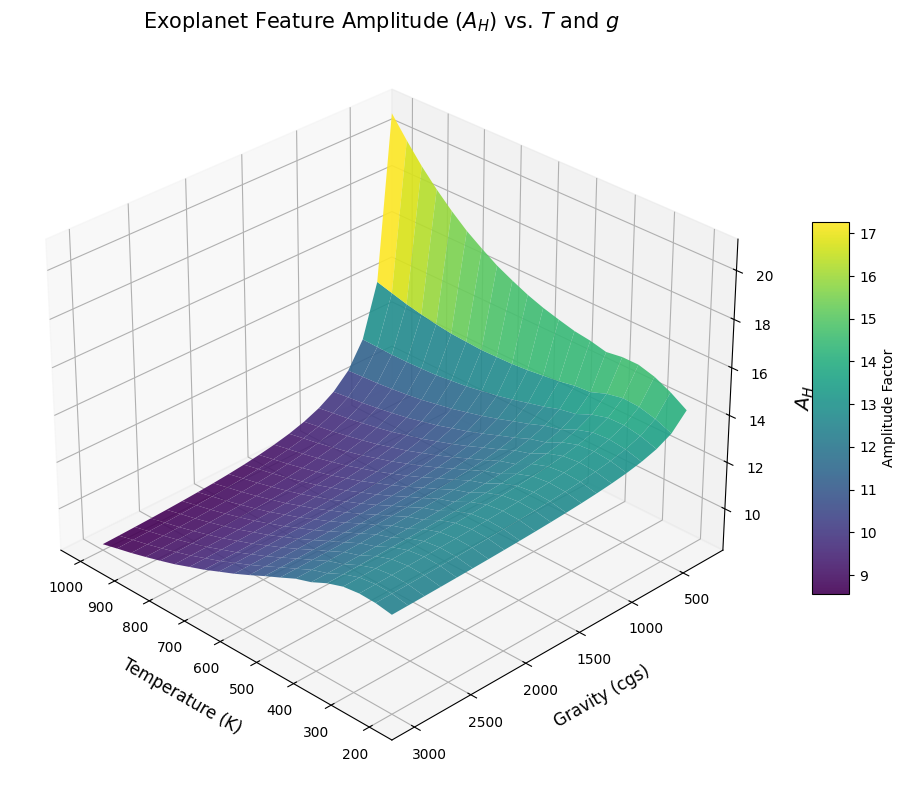

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert your results to numpy arrays (they already mostly are)
T_axis = Temps                  # shape (NT,)
G_axis = gravities              # shape (NG,)
Z = A_H_grid                    # shape (NT, NG)

# 2. Handle any NaNs (just in case)
Z = np.nan_to_num(Z, nan=0.0)

# 3. Create the 2D grid for plotting
# Note: meshgrid order for surface plot is X = Temp, Y = Gravity
T_grid, G_grid = np.meshgrid(T_axis, G_axis, indexing='ij')  

# 4. Initialize 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# filter the plot cos wack extremes
# Z[T_axis > 2100, :] = np.nan
# Z[G_axis < 500, :] = np.nan
#Z[(T_axis[:, None] > 2100) | (G_axis[None, :] < 400)] = np.nan


# T_min, T_max = 0, 2100
# G_min, G_max = 400, 3000

Z_plot = Z.copy()

# Z_plot[
#     (T_axis[:, None] < T_min) |
#     (T_axis[:, None] > T_max) |
#     (G_axis[None, :] < G_min) |
#     (G_axis[None, :] > G_max)
# ] = np.nan


# 5. Plot the surface
surf = ax.plot_surface(T_grid, G_grid, Z_plot, cmap='viridis', 
                       edgecolor='none', alpha=0.9, antialiased=True)

# ax.set_xlim(T_min, T_max)
# ax.set_ylim(G_min, G_max)

# 6. Labels and formatting
ax.set_xlabel('Temperature (K)', fontsize=12, labelpad=10)
ax.set_ylabel('Gravity (cgs)', fontsize=12, labelpad=10)
ax.set_zlabel(r'$A_H$', fontsize=14, labelpad=10)
ax.set_title('Exoplanet Feature Amplitude ($A_H$) vs. $T$ and $g$', fontsize=15)

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Amplitude Factor')

# Viewing angle
ax.view_init(elev=30, azim=135)

plt.tight_layout()
plt.show()


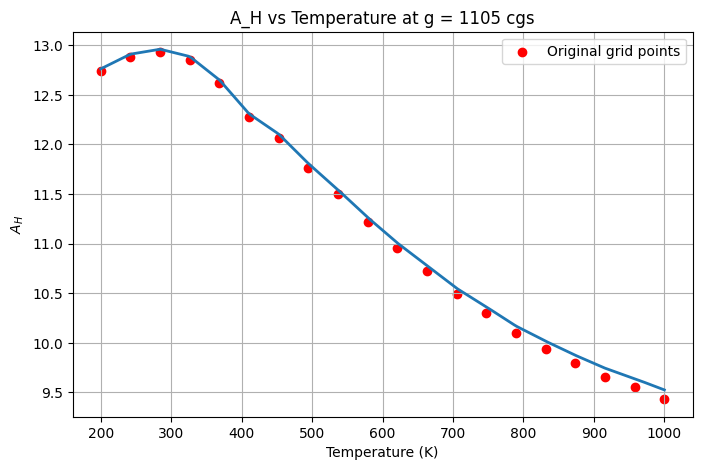

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RegularGridInterpolator

# Assume interp is your RegularGridInterpolator
# Example: pick a gravity value
g_fixed = 1105   # cgs units, pick any value within your grid

# Generate a dense array of temperatures
T_slice = np.linspace(Temps[0], Temps[-1], 200)  # dense T points

# Create points for interpolation (T, g_fixed)
points = np.column_stack([T_slice, np.full_like(T_slice, g_fixed)])

# Interpolate
A_H_slice = interp(points)

# Plot
plt.figure(figsize=(8,5))
plt.plot(T_slice, A_H_slice, lw=2)
plt.scatter(Temps, A_H_grid[:, np.argmin(np.abs(gravities-g_fixed))],
            color='red', label='Original grid points')  # optional: show original grid points
plt.xlabel('Temperature (K)')
plt.ylabel(r'$A_H$')
plt.title(f'A_H vs Temperature at g = {g_fixed:.0f} cgs')
plt.grid(True)
plt.legend()
plt.show()


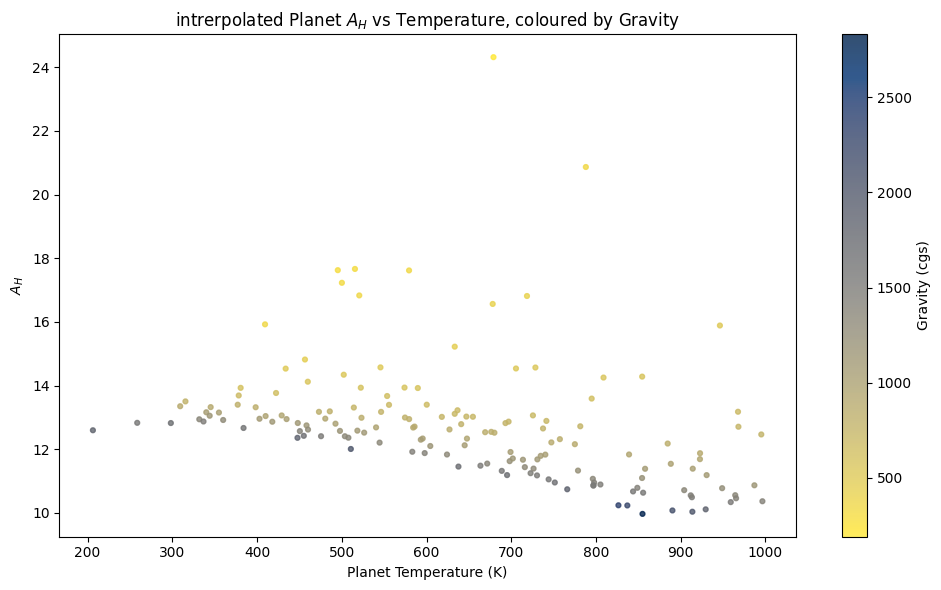

In [ ]:
import pandas as pd

# 1. Load your CSV
df = pd.read_csv(r'C:\Users\Stan\Desktop\UOB physics\Exo group project\github\Group-Studies---Exoplanets\Code\159_planets_all_columns_with_AH.csv')  # replace with your filename

# 2. Extract temperatures and gravities
temps = df['pl_Teq'].values
gravs = df['g_planet_cgs'].values

# 3. Use your interpolator to get A_H for each planet
points = np.column_stack([temps, gravs])
A_H_vals = interp(points)

Rp_actual = df['pl_rade'].values * const.R_earth.value   # planet radius in meters
Rs_actual = df['st_rad'].values * const.R_sun.value      # stellar radius in meters





In [ ]:
#Create the scatter plot


plt.figure(figsize=(10,6))
sc = plt.scatter(temps, A_H_vals, c=gravs, cmap='cividis_r', s=12, alpha=0.8)
#plt.ylim(7,21)
plt.xlabel('Planet Temperature (K)')
plt.ylabel(r'$A_H$')
plt.title('intrerpolated Planet $A_H$ vs Temperature, coloured by Gravity')
cbar = plt.colorbar(sc)
cbar.set_label('Gravity (cgs)')

plt.tight_layout()
plt.show()


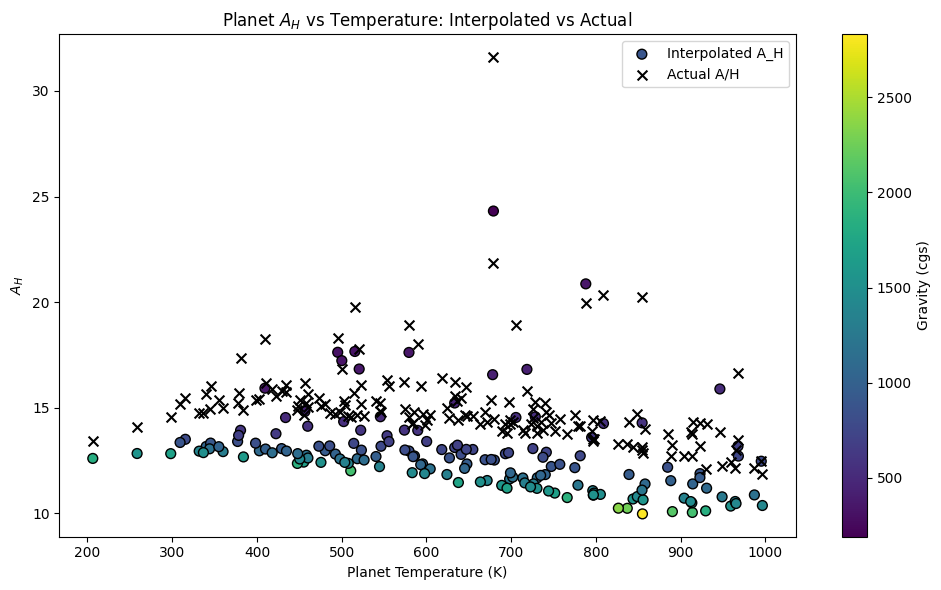

In [84]:


# Load CSV


# Extract temperatures and gravities
temps = df['pl_Teq'].values
gravs = df['g_planet_cgs'].values

# Interpolated A_H from your grid
points = np.column_stack([temps, gravs])
A_H_interp = interp(points)

# Actual A/H column from CSV
A_H_actual = df['A/H'].values

# Plot
plt.figure(figsize=(10,6))

# 1. Interpolated points (colored by gravity)
sc = plt.scatter(temps, A_H_interp, c=gravs, cmap='viridis', s=50, label='Interpolated A_H', edgecolor='k')

# 2. Actual A/H values (black markers, no colour)
plt.scatter(temps, A_H_actual, color='black', marker='x', s=50, label='Actual A/H')

plt.xlabel('Planet Temperature (K)')
plt.ylabel(r'$A_H$')
plt.title('Planet $A_H$ vs Temperature: Interpolated vs Actual')
plt.legend()

# Add colorbar for gravity
cbar = plt.colorbar(sc)
cbar.set_label('Gravity (cgs)')

plt.tight_layout()
plt.show()


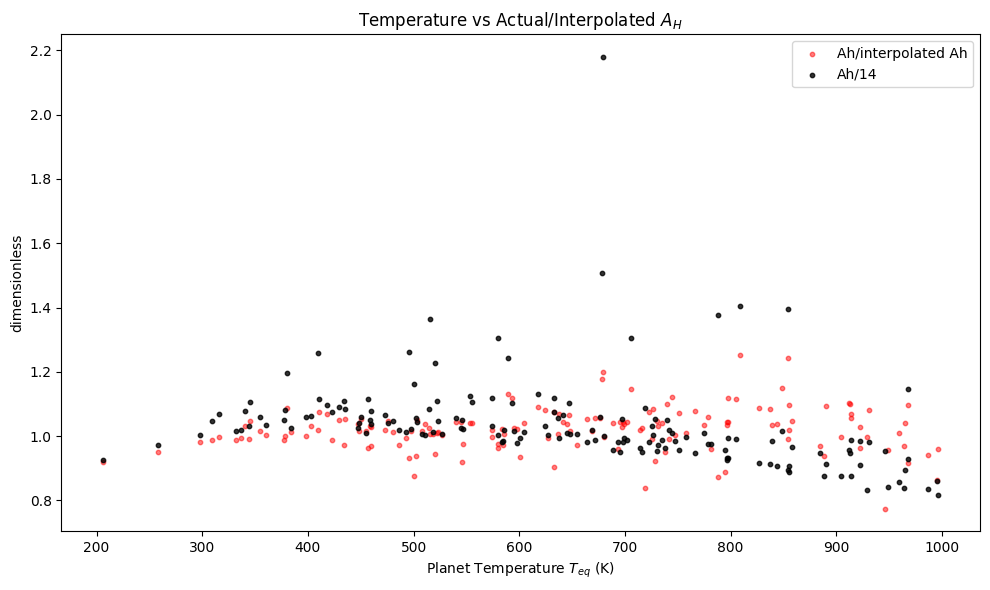

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Compute the ratio of actual to interpolated A_H
ratio1 = A_H_actual / (A_H_interp+2)
ratio2 = A_H_actual / 14.5  # make sure these are numpy arrays

plt.figure(figsize=(10,6))
plt.scatter(df['pl_Teq'], ratio1, s=10, color = 'red',alpha=0.5, label = 'Ah/interpolated Ah')
plt.scatter(df['pl_Teq'], ratio2, s=10, color = 'black', alpha=0.8, label = 'Ah/14')

#plt.axhline(1.0, color='r', linestyle='--', label='Perfect match')
plt.xlabel('Planet Temperature $T_{eq}$ (K)')
plt.ylabel('dimensionless')

plt.title('Temperature vs Actual/Interpolated $A_H$')
plt.legend()
plt.tight_layout()
plt.show()


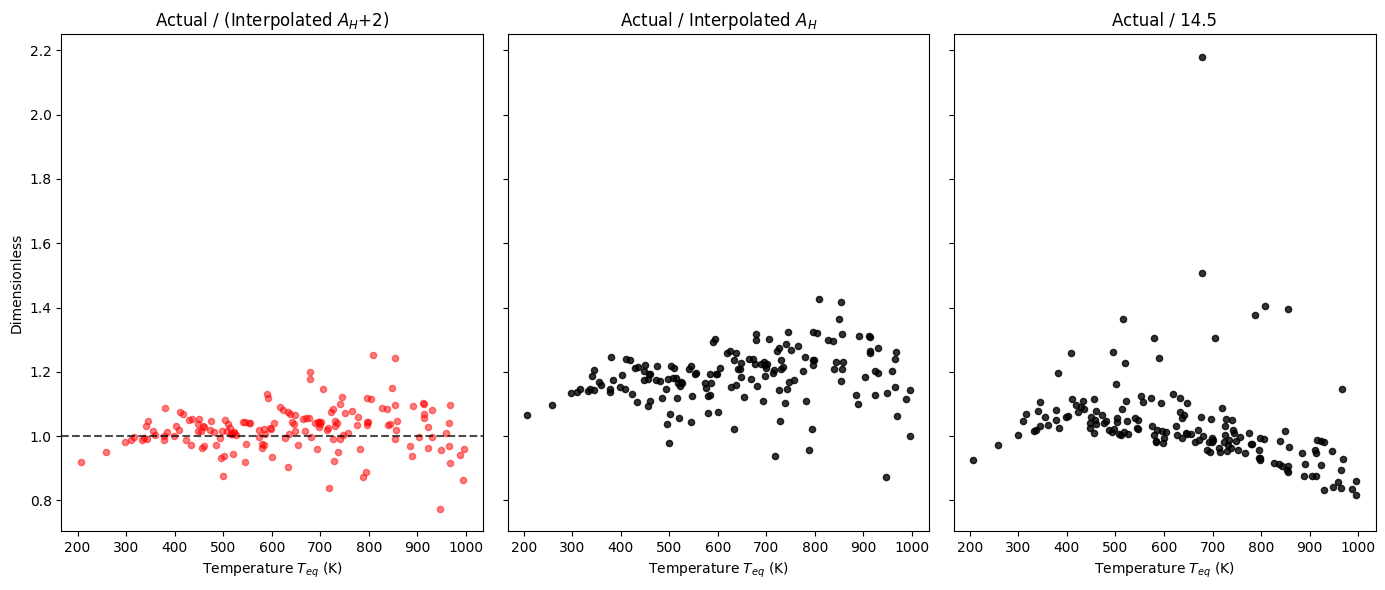

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# Compute ratios
ratio1 = A_H_actual / (A_H_interp+2)
ratio2 = A_H_actual / A_H_interp
ratio3 = A_H_actual / 14.5

# Create side-by-side plots with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)

# Left plot: Actual / Interpolated
axes[0].scatter(df['pl_Teq'], ratio1, s=20, color='red', alpha=0.5)
axes[0].set_xlabel('Temperature $T_{eq}$ (K)')
axes[0].set_ylabel('Dimensionless')
axes[0].set_title('Actual / (Interpolated $A_H$+2)')
axes[0].axhline(1.0, color='k', linestyle='--', alpha=0.7)  # optional reference line

# Right plot: Actual / 14.5
axes[1].scatter(df['pl_Teq'], ratio2, s=20, color='black', alpha=0.8)
axes[1].set_xlabel('Temperature $T_{eq}$ (K)')
axes[1].set_title('Actual / Interpolated $A_H$')

axes[2].scatter(df['pl_Teq'], ratio3, s=20, color='black', alpha=0.8)
axes[2].set_xlabel('Temperature $T_{eq}$ (K)')
axes[2].set_title('Actual / 14.5')

plt.tight_layout()
plt.show()


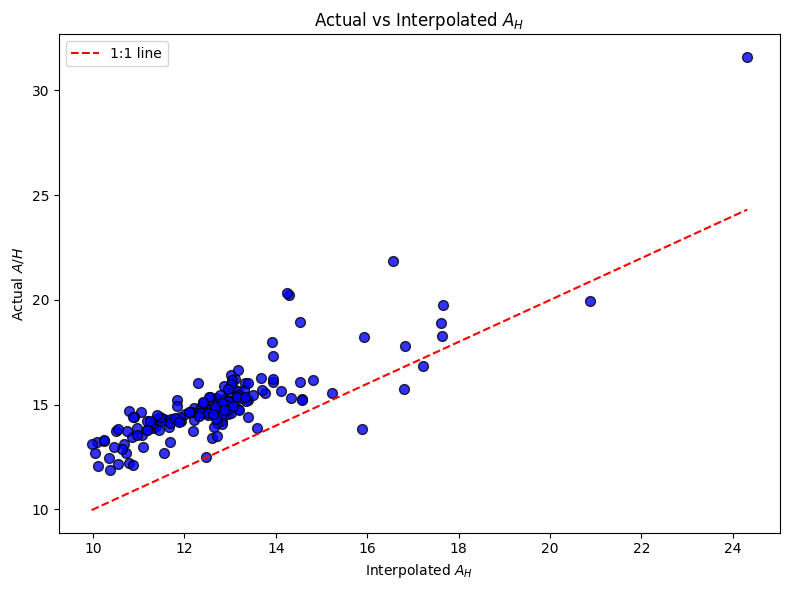

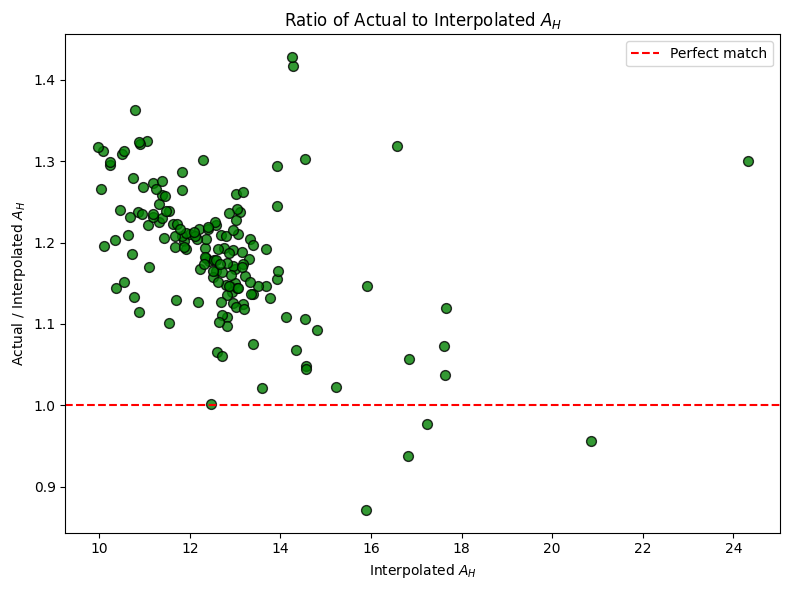

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# ratio of actual to interpolated A_H
ratio = A_H_actual / A_H_interp

plt.figure(figsize=(8,6))
plt.scatter(A_H_interp, A_H_actual, color='blue', s=50, edgecolor='k', alpha=0.8)
plt.plot([min(A_H_interp), max(A_H_interp)], [min(A_H_interp), max(A_H_interp)], 'r--', label='1:1 line')

plt.xlabel('Interpolated $A_H$')
plt.ylabel('Actual $A/H$')
plt.title('Actual vs Interpolated $A_H$')
plt.legend()
plt.tight_layout()
plt.show()

# Optional: ratio plot
plt.figure(figsize=(8,6))
plt.scatter(A_H_interp, ratio, color='green', s=50, edgecolor='k', alpha=0.8)
plt.axhline(1.0, color='r', linestyle='--', label='Perfect match')
plt.xlabel('Interpolated $A_H$')
plt.ylabel('Actual / Interpolated $A_H$')
plt.title('Ratio of Actual to Interpolated $A_H$')
plt.legend()
plt.tight_layout()
plt.show()


ValueError: x and y must be the same size

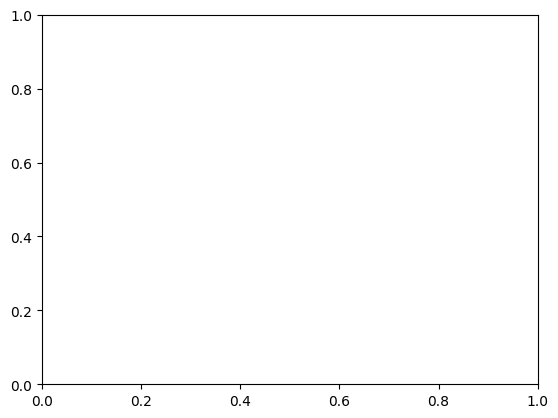

In [38]:
# plt.scatter(tsm_values, A_H_Array, marker='o')
# plt.xlabel('Tsm')
# plt.ylabel('A/H')
# plt.xlim(0, 200)
# plt.ylim(12, 20)
# plt.show()

# plt.scatter(tsm_values, feature_height_ppm_Array, marker='o')
# plt.xlabel('Tsm')
# plt.ylabel('Feature Height (ppm)')
# plt.xlim(0, 200)
# plt.ylim(0, 1000)
# plt.show()

plt.scatter(temps, A_H_Array, marker='o')
plt.xlabel('Temperature (K)')
plt.ylabel('A/H')   
# plt.xlim(0, 500)
# plt.ylim(12, 20)
# plt.ylim(5,15)
plt.show()

plt.scatter(gravity_values, A_H_Array, marker='o')
plt.xlabel('Gravity (cm/s^2)')
plt.ylabel('A/H')   
plt.show()

# plt.scatter(rs_values, A_H_Array, marker='o')
# plt.xlabel('Stellar Radius (Solar Radii)')
# plt.ylabel('A/H')   
# plt.show()

plt.scatter(temp_values, feature_height_ppm_Array, marker='o')
plt.xlabel('Temperature (K)')
plt.ylabel('Feature Height (ppm)')
# plt.xlim(0, 500)
# plt.ylim(0, 1000)
plt.show()